#  Objective 1: Classify Circuit and Driver

**What do we do here?**
Given only one-lap telemetry (Speed, RPM, Throttle, Brake, DRS), we want to predict:
1. Which circuit was this lap run on?
2. Who is the driver?

**Full pipeline:**
```
Raw data (24 races)
    → Cleaning (remove bad laps)
    → Interpolation (each lap = fixed-size vector)
    → PCA (reduce dimensions)
    → Unsupervised: K-Means / GMM (do samples naturally cluster?)
    → Supervised: LDA / SVM / Neural Network (predict labels)
```

## Step 0: Imports

In [1]:
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ML - Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ML - Unsupervised
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

# ML - Supervised
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Enable local cache
fastf1.Cache.enable_cache('../data/raw')

print('✅ Everything imported correctly')

✅ Todo importado correctamente


##  Step 1: Configuration

We define which races to load and which telemetry columns to use.

- `N_GRID_POINTS`: number of uniform points per lap. 1000 means roughly one point every ~5 meters on a 5km circuit.
- `TEL_COLS`: telemetry signals used as features. No GPS or timestamps to avoid data leakage.

In [2]:
# Available circuits (round number, readable name)
RACES = [
    (1,  'Australia'),
    (2,  'China'),
    (3,  'Japan'),
    (4,  'Bahrain'),
    (5,  'Saudi Arabia'),
    (6,  'Miami'),
    (7,  'Emilia Romagna'),
    (8,  'Monaco'),
    (9,  'Spain'),
    (10, 'Canada'),
    (11, 'Austria'),
    (12, 'Britain'),
    (13, 'Belgium'),
    (14, 'Hungary'),
    (15, 'Netherlands'),
    (16, 'Italy'),
    (17, 'Azerbaijan'),
    (18, 'Singapore'),
    (19, 'USA'),
    (20, 'Mexico'),
    (21, 'Brazil'),
    (22, 'Las Vegas'),
    (23, 'Qatar'),
    (24, 'Abu Dhabi'),
]

# Telemetry columns used as features
TEL_COLS = ['Speed', 'RPM', 'nGear', 'Throttle', 'Brake', 'DRS']

# Number of uniform points per lap
N_GRID_POINTS = 1000

# Year
YEAR = 2025

print(f'✅ Configuration ready: {len(RACES)} races, {len(TEL_COLS)} telemetry features, {N_GRID_POINTS} points per lap')

✅ Configuración lista: 24 carreras, 6 features de telemetría, 1000 puntos por vuelta


## Step 2: Data loading and cleaning

**What do we filter and why?**
- `IsAccurate == False`: FastF1 already flags inaccurate laps (first lap, in-lap, out-lap)
- `TrackStatus` contains '4' or '6': Safety Car or Virtual Safety Car — driver pace is not representative
- Non-null `PitInTime` / `PitOutTime`: laps entering or exiting pit lane — incomplete laps

⚠️ **This cell takes several minutes** because it loads telemetry from 24 races.

In [3]:
def load_and_clean_race(year, round_num, circuit_name):
    """
    Load one race session and return cleaned laps.
    Return None if an error occurs.
    """
    try:
        session = fastf1.get_session(year, round_num, 'R')
        session.load(telemetry=True, weather=False, messages=False)
        laps = session.laps.copy()
        
        # Filter 1: remove laps marked as inaccurate
        laps = laps[laps['IsAccurate'] == True]
        
        # Filter 2: remove Safety Car / Virtual Safety Car laps
        laps = laps[~laps['TrackStatus'].str.contains('4|6', na=False)]
        
        # Filter 3: remove in-laps and out-laps
        laps = laps[laps['PitInTime'].isnull() & laps['PitOutTime'].isnull()]
        
        # Add circuit label
        laps['Circuit'] = circuit_name
        
        return laps, session
    
    except Exception as e:
        print(f'  ❌ Error in {circuit_name}: {e}')
        return None, None


# Load all races
all_laps = []
sessions = {}

for round_num, circuit_name in RACES:
    print(f'Loading {circuit_name}...', end=' ')
    laps, session = load_and_clean_race(YEAR, round_num, circuit_name)
    
    if laps is not None and len(laps) > 0:
        all_laps.append(laps)
        sessions[circuit_name] = session
        print(f'✅ {len(laps)} clean laps')
    else:
        print('⚠️ No data')

# Merge everything into one DataFrame
laps_df = pd.concat(all_laps, ignore_index=True)

print(f'\n📊 Total clean laps: {len(laps_df)}')
print(f'   Circuits: {laps_df["Circuit"].nunique()}')
print(f'   Drivers: {laps_df["Driver"].nunique()}')
print(f'\nDistribution by circuit:')
print(laps_df.groupby("Circuit")["Driver"].count().sort_values(ascending=False))

Cargando Australia... 

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INF

✅ 568 vueltas limpias
Cargando China... 

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '63', '1', '31', '12', '23', '87', '18', '55', '6', '30', '7', '5', '27', '22', '14', '16', '44', '10']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


✅ 995 vueltas limpias
Cargando Japan... 

...

✅ 760 vueltas limpias
Cargando Qatar... 

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


✅ 922 vueltas limpias
Cargando Abu Dhabi... 

req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


✅ 1082 vueltas limpias

📊 Total vueltas limpias: 23043
   Circuitos: 24
   Pilotos: 21

Distribución por circuito:
Circuit
Hungary           1289
Monaco            1271
Canada            1197
Singapore         1163
Mexico            1153
Abu Dhabi         1082
Brazil            1049
Netherlands       1041
Austria           1010
Japan              997
China              995
Spain              990
USA                963
Emilia Romagna     956
Bahrain            952
Qatar              922
Italy              916
Miami              861
Azerbaijan         855
Saudi Arabia       810
Las Vegas          760
Belgium            747
Australia          568
Britain            496
Name: Driver, dtype: int64


## 📐 Step 3: Interpolation to a uniform grid

**Why is this needed?**

Each lap has a different number of telemetry points (roughly ~300 to ~800 depending on circuit and speed). ML models require all vectors to have exactly the same size.

**Solution:** For each lap, create a uniform distance grid [0, 5, 10, ..., total_distance] and interpolate each signal on that grid.

**Result:** Each lap → vector of `N_GRID_POINTS × len(TEL_COLS)` = 1000 × 6 = **6000 values**.

In [7]:
def resolve_lap_from_row(row, sessions_by_circuit):
    """Recover the FastF1 Lap object from a row in laps_df."""
    circuit = row['Circuit']
    driver = row['Driver']
    lap_number = row['LapNumber']

    if circuit not in sessions_by_circuit:
        return None

    session_laps = sessions_by_circuit[circuit].laps
    matches = session_laps.pick_drivers(driver)
    matches = matches[matches['LapNumber'] == lap_number]

    if len(matches) == 0:
        return None

    # If multiple matches exist, pick the first one.
    return matches.iloc[0]


def interpolate_lap(lap_obj, tel_cols, n_points):
    """Convert one FastF1 Lap object into a fixed-size telemetry vector."""
    try:
        tel = lap_obj.get_car_data().add_distance()
        if tel is None or len(tel) < 10:
            return None

        dist = pd.to_numeric(tel['Distance'], errors='coerce').to_numpy(dtype=float)
        valid_dist = np.isfinite(dist)
        if valid_dist.sum() < 10:
            return None

        dist = dist[valid_dist]
        if dist.max() <= 0:
            return None

        order = np.argsort(dist)
        dist_sorted = dist[order]
        unique_idx = np.unique(dist_sorted, return_index=True)[1]
        dist_unique = dist_sorted[unique_idx]
        if len(dist_unique) < 10:
            return None

        grid = np.linspace(0.0, float(dist_unique[-1]), n_points)

        interpolated = []
        for col in tel_cols:
            if col not in tel.columns:
                return None

            signal = pd.to_numeric(tel[col], errors='coerce').to_numpy(dtype=float)
            signal = signal[valid_dist][order][unique_idx]

            finite = np.isfinite(signal)
            if finite.sum() < 10:
                return None

            interp_signal = np.interp(grid, dist_unique[finite], signal[finite])
            interpolated.append(interp_signal)

        return np.concatenate(interpolated)
    except Exception:
        return None


print('Interpolating telemetry... (this can take several minutes)')

vectors = []
labels_circuit = []
labels_driver = []
meta = []
skipped_no_lap = 0
skipped_bad_tel = 0

total = len(laps_df)
for i, (_, row) in enumerate(laps_df.iterrows()):
    if i % 500 == 0:
        print(f'  {i}/{total} laps processed...')

    lap_obj = resolve_lap_from_row(row, sessions)
    if lap_obj is None:
        skipped_no_lap += 1
        continue

    vec = interpolate_lap(lap_obj, TEL_COLS, N_GRID_POINTS)
    if vec is None:
        skipped_bad_tel += 1
        continue

    vectors.append(vec)
    labels_circuit.append(row['Circuit'])
    labels_driver.append(row['Driver'])
    meta.append({'Circuit': row['Circuit'], 'Driver': row['Driver'], 'LapNumber': row['LapNumber']})

if len(vectors) == 0:
    raise RuntimeError(
        'No valid interpolated laps were generated. '\
        f'Skipped (lap not found): {skipped_no_lap}, skipped (bad telemetry): {skipped_bad_tel}'
    )

X = np.array(vectors, dtype=float)
y_circuit = np.array(labels_circuit)
y_driver = np.array(labels_driver)
meta_df = pd.DataFrame(meta)

print('\n✅ Interpolation completed')
print(f'   X shape: {X.shape}  → {X.shape[0]} laps × {X.shape[-1]} features')
print(f'   Unique circuits: {len(np.unique(y_circuit))}')
print(f'   Unique drivers: {len(np.unique(y_driver))}')
print(f'   Skipped (lap not found): {skipped_no_lap}')
print(f'   Skipped (bad telemetry): {skipped_bad_tel}')

Interpolating telemetry... (this can take several minutes)
  0/23043 laps processed...
  500/23043 laps processed...
  1000/23043 laps processed...
  1500/23043 laps processed...
  2000/23043 laps processed...
  2500/23043 laps processed...
  3000/23043 laps processed...
  3500/23043 laps processed...
  4000/23043 laps processed...
  4500/23043 laps processed...
  5000/23043 laps processed...
  5500/23043 laps processed...
  6000/23043 laps processed...
  6500/23043 laps processed...
  7000/23043 laps processed...
  7500/23043 laps processed...
  8000/23043 laps processed...
  8500/23043 laps processed...
  9000/23043 laps processed...
  9500/23043 laps processed...
  10000/23043 laps processed...
  10500/23043 laps processed...
  11000/23043 laps processed...
  11500/23043 laps processed...
  12000/23043 laps processed...
  12500/23043 laps processed...
  13000/23043 laps processed...
  13500/23043 laps processed...
  14000/23043 laps processed...
  14500/23043 laps processed...
  150

## 📉 Step 4: Normalization + PCA

**Why normalize?**
Speed ranges from 0 to 350 km/h, while Throttle ranges from 0 to 100%. Without normalization, Speed dominates and the other signals are underused. We use `StandardScaler` so all features have mean=0 and std=1.

**Why PCA?**
We have 6000 dimensions per lap. Many are correlated (when you accelerate, RPM also increases). PCA finds directions of maximum variance and reduces to ~50 components while preserving ~95% of information. This makes models faster and helps reduce overfitting.

✅ Normalization completed


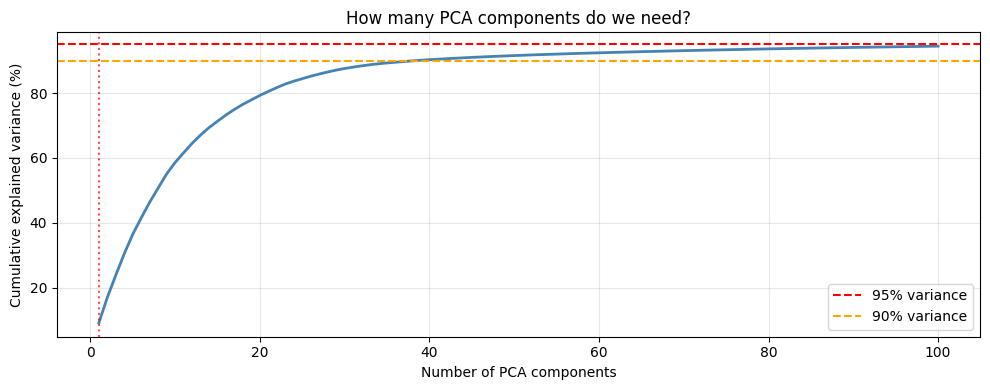


📊 To explain 95% of variance we need: 1 components
   (we reduce from 6000 → 1 dimensions)


In [8]:
# Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('✅ Normalization completed')

# PCA - choose a safe maximum number of components
max_components = min(100, X_scaled.shape[0], X_scaled.shape[1])
if max_components < 2:
    raise RuntimeError(
        f'Not enough samples/features for PCA. X shape: {X_scaled.shape}. '
        'You need at least 2 valid laps after interpolation.'
    )

pca_full = PCA(n_components=max_components)
pca_full.fit(X_scaled)

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Cumulative variance plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, max_components + 1), cumvar * 100, color='steelblue', linewidth=2)
ax.axhline(95, color='red', linestyle='--', label='95% variance')
ax.axhline(90, color='orange', linestyle='--', label='90% variance')
n_95 = np.argmax(cumvar >= 0.95) + 1
ax.axvline(n_95, color='red', linestyle=':', alpha=0.7)
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('How many PCA components do we need?')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n📊 To explain 95% of variance we need: {n_95} components')
print(f'   (we reduce from {X_scaled.shape[1]} → {n_95} dimensions; max tested = {max_components})')

✅ PCA applied: 6000 → 2 dimensions
   Explained variance: 17.0%


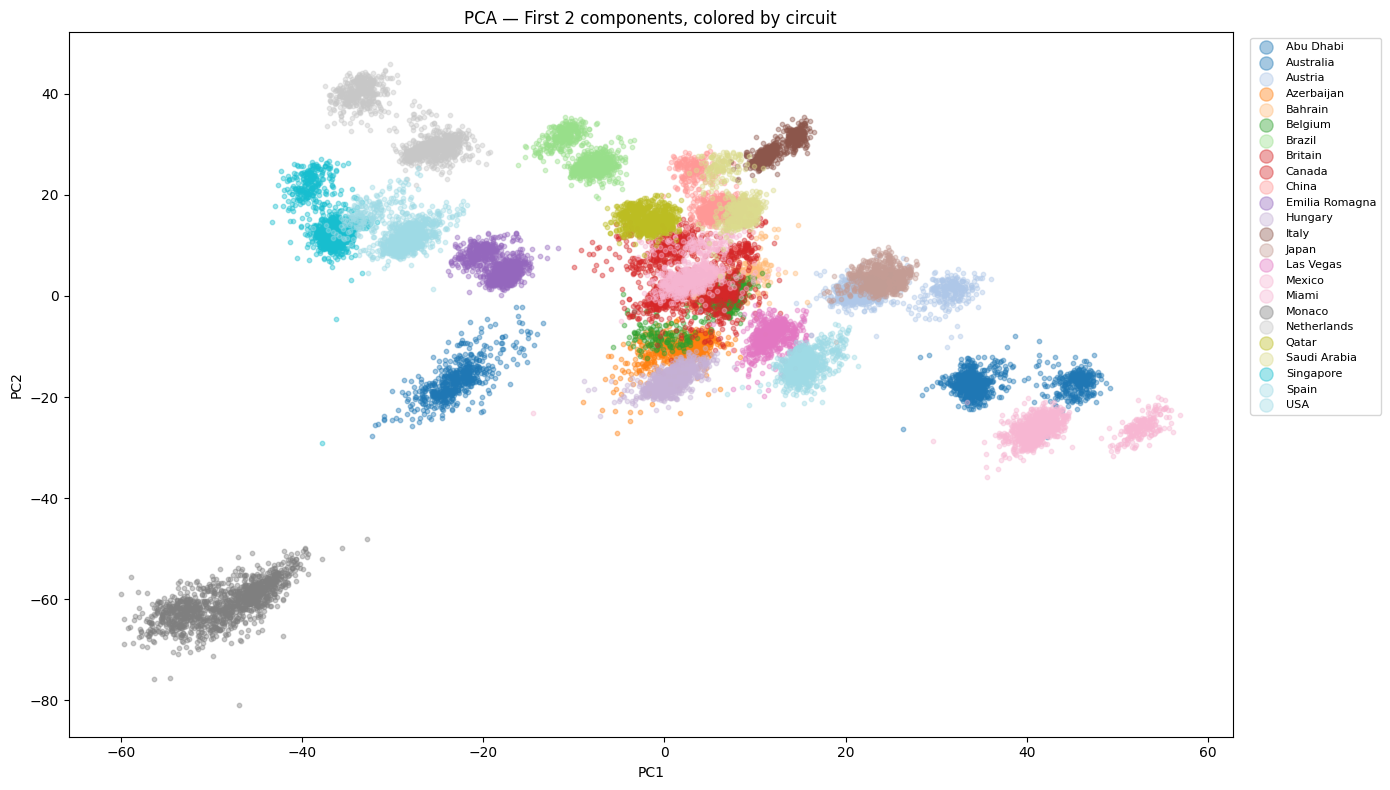

In [21]:
# Apply PCA with the number of components needed for 95% variance
max_components = min(X_scaled.shape[0], X_scaled.shape[1])
N_COMPONENTS = min(max(2, n_95), max_components) if max_components >= 2 else 1

pca = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_scaled)

print(f'✅ PCA applied: {X_scaled.shape[1]} → {X_pca.shape[1]} dimensions')
print(f'   Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

# Visualization of PCA components
circuits = np.unique(y_circuit)
colors = plt.cm.tab20(np.linspace(0, 1, len(circuits)))
circuit_to_color = {c: colors[i] for i, c in enumerate(circuits)}

fig, ax = plt.subplots(figsize=(14, 8))
if X_pca.shape[1] >= 2:
    for circuit in circuits:
        mask = y_circuit == circuit
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[circuit_to_color[circuit]], label=circuit,
                   alpha=0.4, s=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title('PCA — First 2 components, colored by circuit')
else:
    for circuit in circuits:
        mask = y_circuit == circuit
        ax.scatter(X_pca[mask, 0], np.zeros(mask.sum()),
                   c=[circuit_to_color[circuit]], label=circuit,
                   alpha=0.6, s=16)
    ax.set_xlabel('PC1')
    ax.set_ylabel('')
    ax.set_title('PCA — Only 1 component available (plotting PC1)')

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, markerscale=3)
plt.tight_layout()
plt.show()

## 🔵 Step 5: Unsupervised Clustering (K-Means and GMM)

**What do we do here?**
Before using labels, we ask: do the data naturally cluster in a meaningful way?

If K-Means with K=24 finds clusters that match the 24 circuits, it means telemetry alone can separate circuits. That validates the problem as learnable.

**Metrics:**
- **Silhouette Score**: how well separated clusters are (1 = perfect, 0 = overlapping)
- **Adjusted Rand Index (ARI)**: how well clusters match true labels (1 = perfect)

In [22]:
# ---- K-Means for CIRCUIT clustering ----
print('='*50)
print('K-MEANS — CIRCUIT clustering')
print('='*50)

n_circuits = len(np.unique(y_circuit))
kmeans_circuit = KMeans(n_clusters=n_circuits, random_state=42, n_init=10)
circuit_cluster_labels = kmeans_circuit.fit_predict(X_pca)

# Metrics
le_circuit = LabelEncoder()
y_circuit_encoded = le_circuit.fit_transform(y_circuit)

ari_circuit = adjusted_rand_score(y_circuit_encoded, circuit_cluster_labels)
sil_circuit = silhouette_score(X_pca, circuit_cluster_labels, sample_size=2000)

print(f'  Adjusted Rand Index (ARI): {ari_circuit:.3f}  (1.0 = perfect)')
print(f'  Silhouette Score:          {sil_circuit:.3f}  (1.0 = perfectly separated clusters)')

print()

# ---- K-Means for DRIVER clustering ----
print('='*50)
print('K-MEANS — DRIVER clustering')
print('='*50)

n_drivers = len(np.unique(y_driver))
kmeans_driver = KMeans(n_clusters=n_drivers, random_state=42, n_init=10)
driver_cluster_labels = kmeans_driver.fit_predict(X_pca)

le_driver = LabelEncoder()
y_driver_encoded = le_driver.fit_transform(y_driver)

ari_driver = adjusted_rand_score(y_driver_encoded, driver_cluster_labels)
sil_driver = silhouette_score(X_pca, driver_cluster_labels, sample_size=2000)

print(f'  Adjusted Rand Index (ARI): {ari_driver:.3f}  (1.0 = perfect)')
print(f'  Silhouette Score:          {sil_driver:.3f}  (1.0 = perfectly separated clusters)')

K-MEANS — CIRCUIT clustering
  Adjusted Rand Index (ARI): 0.655  (1.0 = perfect)
  Silhouette Score:          0.546  (1.0 = perfectly separated clusters)

K-MEANS — DRIVER clustering
  Adjusted Rand Index (ARI): 0.003  (1.0 = perfect)
  Silhouette Score:          0.558  (1.0 = perfectly separated clusters)


In [11]:
# ---- GMM for CIRCUIT clustering ----
# GMM is more flexible than K-Means: it allows elliptical clusters
print('='*50)
print('GMM — CIRCUIT clustering')
print('='*50)

gmm_circuit = GaussianMixture(n_components=n_circuits, random_state=42, covariance_type='diag')
gmm_circuit_labels = gmm_circuit.fit_predict(X_pca)

ari_gmm_circuit = adjusted_rand_score(y_circuit_encoded, gmm_circuit_labels)
sil_gmm_circuit = silhouette_score(X_pca, gmm_circuit_labels, sample_size=2000)

print(f'  GMM ARI Circuit:  {ari_gmm_circuit:.3f}')
print(f'  GMM Silhouette:   {sil_gmm_circuit:.3f}')

print()

# Comparative summary
print('='*50)
print('UNSUPERVISED SUMMARY')
print('='*50)
summary = pd.DataFrame({
    'Model': ['K-Means', 'K-Means', 'GMM'],
    'Target': ['Circuit', 'Driver', 'Circuit'],
    'ARI': [ari_circuit, ari_driver, ari_gmm_circuit],
    'Silhouette': [sil_circuit, sil_driver, sil_gmm_circuit]
})
print(summary.to_string(index=False))

GMM — CIRCUIT clustering
  GMM ARI Circuit:  0.398
  GMM Silhouette:   0.548

UNSUPERVISED SUMMARY
  Model  Target      ARI  Silhouette
K-Means Circuit 0.386422    0.553526
K-Means  Driver 0.004137    0.567075
    GMM Circuit 0.398385    0.548391


## 🟢 Step 6: Supervised Classification

Now we use true labels to train classification models.

**Train/Test split:** 80% for training, 20% for evaluation. Stratified so all circuits/drivers are proportionally represented in both sets.

**Models:**
- **LDA**: assumes each class follows a Gaussian distribution with shared covariance. Fast and interpretable.
- **SVM**: finds the hyperplane that maximizes margin between classes. Very strong in high-dimensional spaces.
- **MLP (Neural Network)**: multi-layer neural network. More flexible but slower.

In [12]:
# ---- Train/Test Split ----

# For circuit
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pca, y_circuit, test_size=0.2, random_state=42, stratify=y_circuit
)

# For driver
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_pca, y_driver, test_size=0.2, random_state=42, stratify=y_driver
)

print(f'✅ Split completed')
print(f'   Train: {len(X_train_c)} laps')
print(f'   Test:  {len(X_test_c)} laps')

✅ Split completed
   Train: 18427 laps
   Test:  4607 laps


In [23]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, target_name):
    """Train, evaluate, and print model results."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = (y_pred == y_test).mean()
    
    print(f'\n{name} — {target_name}')
    print(f'  Test accuracy: {acc*100:.1f}%')
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return model, y_pred, acc


results = {}  # store final summary

In [24]:
# ---- LDA ----
print('='*60)
print('LINEAR DISCRIMINANT ANALYSIS (LDA)')
print('='*60)

lda_c = LinearDiscriminantAnalysis()
lda_c, pred_lda_c, acc_lda_c = evaluate_model(
    'LDA', lda_c, X_train_c, y_train_c, X_test_c, y_test_c, 'CIRCUIT'
)
results['LDA - Circuit'] = acc_lda_c

lda_d = LinearDiscriminantAnalysis()
lda_d, pred_lda_d, acc_lda_d = evaluate_model(
    'LDA', lda_d, X_train_d, y_train_d, X_test_d, y_test_d, 'DRIVER'
)
results['LDA - Driver'] = acc_lda_d

LINEAR DISCRIMINANT ANALYSIS (LDA)

LDA — CIRCUIT
  Test accuracy: 52.2%
                precision    recall  f1-score   support

     Abu Dhabi       0.64      0.68      0.66       217
     Australia       0.57      0.56      0.56       114
       Austria       0.46      0.67      0.55       202
    Azerbaijan       0.00      0.00      0.00       171
       Bahrain       0.15      0.22      0.18       190
       Belgium       0.00      0.00      0.00       149
        Brazil       0.96      0.96      0.96       210
       Britain       0.00      0.00      0.00        99
        Canada       0.00      0.00      0.00       240
         China       0.30      0.58      0.40       199
Emilia Romagna       0.84      0.95      0.89       191
       Hungary       0.29      0.88      0.43       258
         Italy       0.41      0.67      0.51       181
         Japan       0.61      0.21      0.31       199
     Las Vegas       0.00      0.00      0.00       152
        Mexico       0.73     

In [25]:
# ---- SVM ----
print('='*60)
print('SUPPORT VECTOR MACHINE (SVM)')
print('='*60)
print('(can take 1-2 minutes...)')

svm_c = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_c, pred_svm_c, acc_svm_c = evaluate_model(
    'SVM', svm_c, X_train_c, y_train_c, X_test_c, y_test_c, 'CIRCUIT'
)
results['SVM - Circuit'] = acc_svm_c

svm_d = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_d, pred_svm_d, acc_svm_d = evaluate_model(
    'SVM', svm_d, X_train_d, y_train_d, X_test_d, y_test_d, 'DRIVER'
)
results['SVM - Driver'] = acc_svm_d

SUPPORT VECTOR MACHINE (SVM)
(can take 1-2 minutes...)

SVM — CIRCUIT
  Test accuracy: 59.3%
                precision    recall  f1-score   support

     Abu Dhabi       0.88      0.61      0.72       217
     Australia       0.64      0.39      0.48       114
       Austria       0.76      0.67      0.71       202
    Azerbaijan       0.12      0.02      0.03       171
       Bahrain       0.00      0.00      0.00       190
       Belgium       0.24      0.09      0.13       149
        Brazil       0.96      0.96      0.96       210
       Britain       0.00      0.00      0.00        99
        Canada       0.00      0.00      0.00       240
         China       0.31      0.71      0.43       199
Emilia Romagna       0.85      0.94      0.89       191
       Hungary       0.33      0.79      0.47       258
         Italy       0.44      0.65      0.52       181
         Japan       0.78      0.85      0.82       199
     Las Vegas       0.00      0.00      0.00       152
        Me

In [28]:
# ---- Neural Network (MLP) ----
print('='*60)
print('NEURAL NETWORK (MLP)')
print('='*60)
print('(can take several minutes...)')

mlp_c = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=False
)
mlp_c, pred_mlp_c, acc_mlp_c = evaluate_model(
    'MLP', mlp_c, X_train_c, y_train_c, X_test_c, y_test_c, 'CIRCUIT'
)
results['MLP - Circuit'] = acc_mlp_c

mlp_d = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=False
)
mlp_d, pred_mlp_d, acc_mlp_d = evaluate_model(
    'MLP', mlp_d, X_train_d, y_train_d, X_test_d, y_test_d, 'DRIVER'
)
results['MLP - Driver'] = acc_mlp_d

NEURAL NETWORK (MLP)
(can take several minutes...)

MLP — CIRCUIT
  Test accuracy: 58.9%
                precision    recall  f1-score   support

     Abu Dhabi       0.73      0.82      0.78       217
     Australia       0.55      0.33      0.42       114
       Austria       0.77      0.60      0.67       202
    Azerbaijan       0.23      0.28      0.25       171
       Bahrain       0.28      0.28      0.28       190
       Belgium       0.31      0.30      0.31       149
        Brazil       0.95      0.97      0.96       210
       Britain       0.00      0.00      0.00        99
        Canada       0.26      0.27      0.27       240
         China       0.33      0.32      0.32       199
Emilia Romagna       0.86      0.91      0.88       191
       Hungary       0.36      0.48      0.42       258
         Italy       0.55      0.28      0.37       181
         Japan       0.75      0.88      0.81       199
     Las Vegas       0.45      0.55      0.50       152
        Mexico

## 📊 Step 7: Results visualization

FINAL SUMMARY — TEST SET ACCURACY
Model  Target  Accuracy (%)
  LDA Circuit          52.2
  LDA  Driver           5.6
  SVM Circuit          59.3
  SVM  Driver           5.1
  MLP Circuit          58.9
  MLP  Driver           6.7


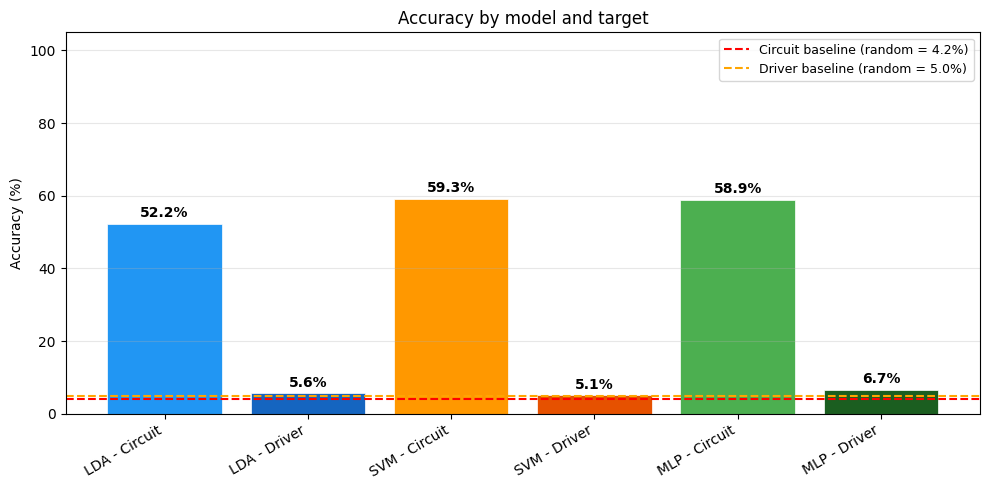

In [29]:
# ---- Final accuracy summary ----
print('='*60)
print('FINAL SUMMARY — TEST SET ACCURACY')
print('='*60)

summary_df = pd.DataFrame([
    {'Model': k.split(' - ')[0], 'Target': k.split(' - ')[1], 'Accuracy': v}
    for k, v in results.items()
])
summary_df['Accuracy (%)'] = (summary_df['Accuracy'] * 100).round(1)
print(summary_df[['Model', 'Target', 'Accuracy (%)']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
bars = ax.bar(x, [v*100 for v in results.values()], 
               color=['#2196F3', '#1565C0', '#FF9800', '#E65100', '#4CAF50', '#1B5E20'],
               edgecolor='white', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(list(results.keys()), rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by model and target')
ax.set_ylim(0, 105)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(100/24, color='red', linestyle='--', label=f'Circuit baseline (random = {100/24:.1f}%)')
ax.axhline(100/20, color='orange', linestyle='--', label=f'Driver baseline (random = {100/20:.1f}%)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

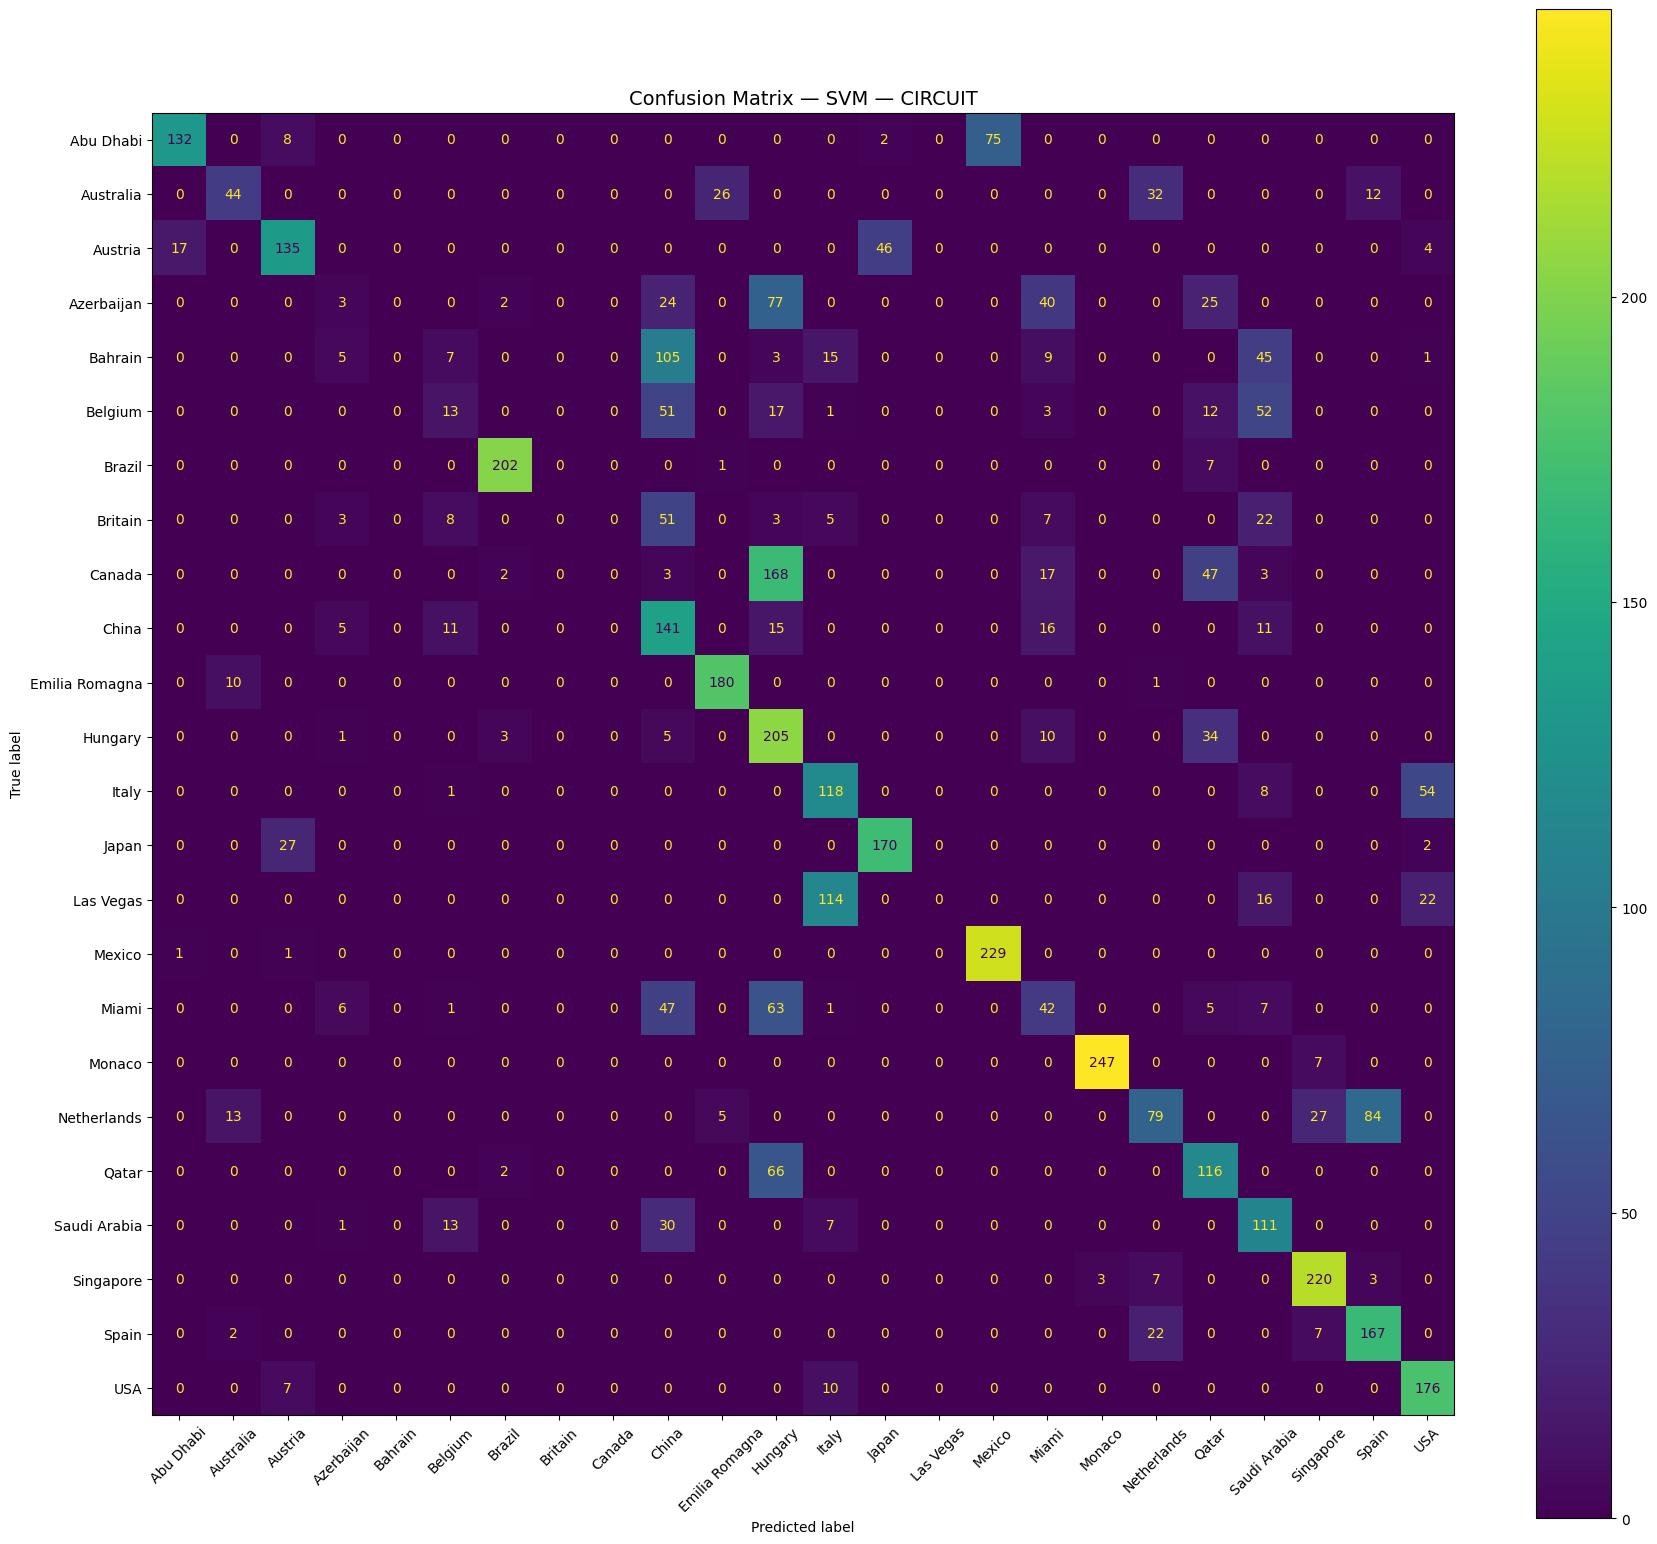

Each row = true circuit. Each column = model prediction.
Diagonal = correct predictions. Off-diagonal = errors.


In [30]:
# ---- Confusion matrix: best model for circuit ----
# Use the model with the best circuit accuracy
best_circuit = max(
    [('LDA', pred_lda_c, acc_lda_c), ('SVM', pred_svm_c, acc_svm_c), ('MLP', pred_mlp_c, acc_mlp_c)],
    key=lambda x: x[2]
)
nombre_best, pred_best_c, _ = best_circuit

fig, ax = plt.subplots(figsize=(18, 16))
cm = confusion_matrix(y_test_c, pred_best_c, labels=np.unique(y_circuit))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_circuit))
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title(f'Confusion Matrix — {nombre_best} — CIRCUIT', fontsize=14)
plt.tight_layout()
plt.show()
print('Each row = true circuit. Each column = model prediction.')
print('Diagonal = correct predictions. Off-diagonal = errors.')

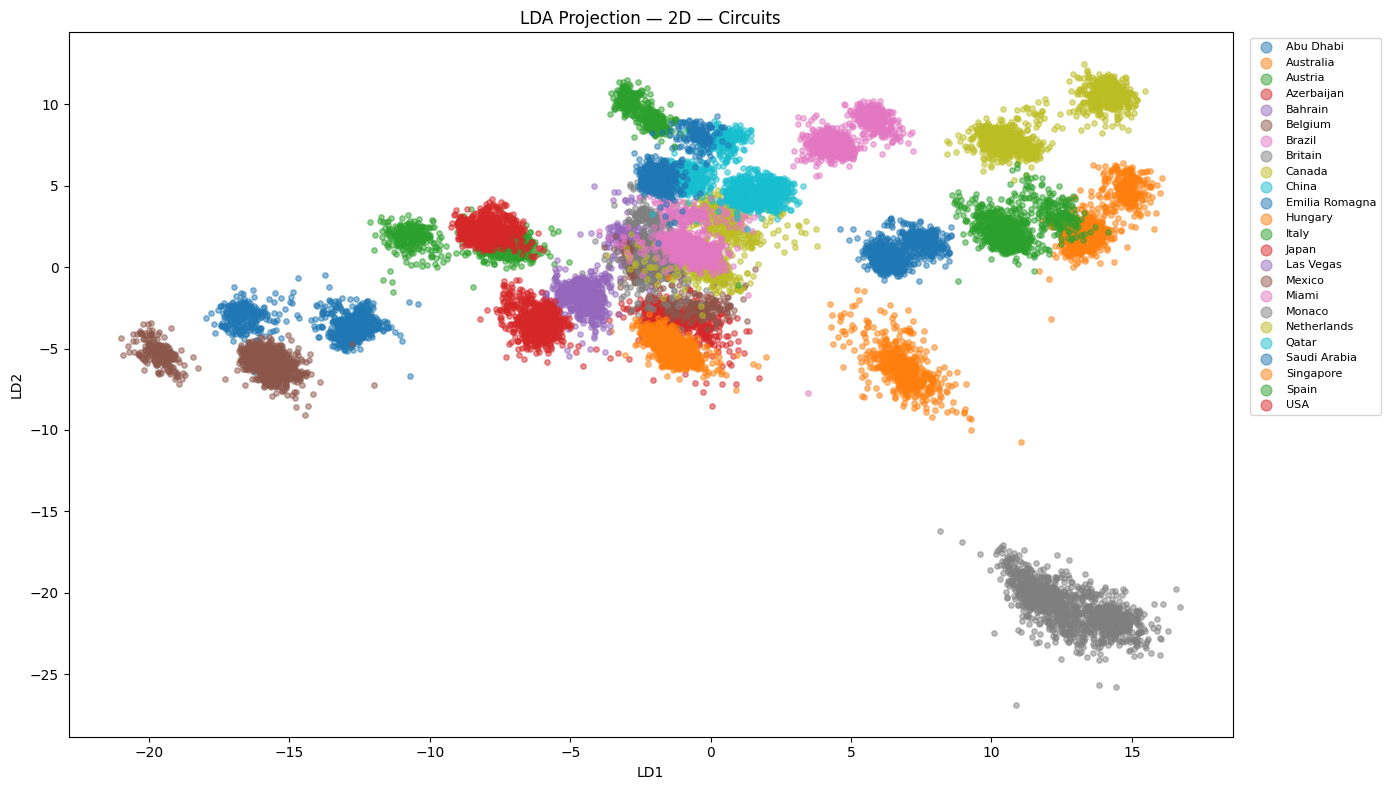

If circuits form separate clusters in this plot, the model can discriminate them well.


In [31]:
# ---- LDA projection for visualization ----
# LDA can also project data into a 2D space that separates classes
lda_vis = LinearDiscriminantAnalysis(n_components=2)
X_lda_2d = lda_vis.fit_transform(X_pca, y_circuit)

fig, ax = plt.subplots(figsize=(14, 8))
for circuit in np.unique(y_circuit):
    mask = y_circuit == circuit
    ax.scatter(X_lda_2d[mask, 0], X_lda_2d[mask, 1],
               label=circuit, alpha=0.5, s=15)

ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('LDA Projection — 2D — Circuits')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()
print('If circuits form separate clusters in this plot, the model can discriminate them well.')